# Exploratory Data Analysis

This notebook covers:
1. Dataset overview and descriptive statistics
2. Feature assessment and visualization

Dataset details: 242 patient records, 13 input features and binary target `num` (`0`: no disease, `1`: disease).

In [57]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

SEED = 42
np.random.seed(SEED)

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 6)

FIGURES_DIR = Path('..') / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## 1. Dataset Overview and Descriptive Statistics

In [58]:
data_path = Path('..') / 'data' / 'students_dataset.csv'
df = pd.read_csv(data_path)

print(f'Dataset path: {data_path}')
print(f'Shape: {df.shape[0]} rows x {df.shape[1]} columns')
display(df.head())

Dataset path: ../data/students_dataset.csv
Shape: 242 rows x 14 columns


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,48.0,1.0,4.0,124.0,274.0,0.0,2.0,166.0,0.0,0.5,2.0,0.0,7.0,1
1,55.0,1.0,2.0,130.0,262.0,0.0,0.0,155.0,0.0,0.0,1.0,0.0,3.0,0
2,54.0,0.0,2.0,132.0,288.0,1.0,2.0,159.0,1.0,0.0,1.0,1.0,3.0,0
3,54.0,1.0,2.0,108.0,309.0,0.0,0.0,156.0,0.0,0.0,1.0,0.0,7.0,0
4,57.0,0.0,4.0,140.0,241.0,0.0,0.0,123.0,1.0,0.2,2.0,0.0,7.0,1


In [59]:
print('Column dtypes:')
display(df.dtypes.to_frame('dtype'))

print('Duplicate rows:', df.duplicated().sum())

missing_summary = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_percent': (df.isna().mean() * 100).round(2)
}).sort_values('missing_count', ascending=False)

display(missing_summary)

Column dtypes:


,dtype
age,float64
sex,float64
cp,float64
trestbps,float64
chol,float64
fbs,float64
restecg,float64
thalach,float64
exang,float64
oldpeak,float64


Duplicate rows: 0


,missing_count,missing_percent
ca,1,0.41
thal,1,0.41
age,0,0.00
sex,0,0.00
cp,0,0.00
trestbps,0,0.00
chol,0,0.00
fbs,0,0.00
restecg,0,0.00
thalach,0,0.00


### Feature schema and value-range validation

This validation table checks observed encodings and value ranges

- Variables are grouped by semantic role, not solely by numeric storage type.
- Observed encodings in this file differ from some descriptions given. For example, `cp` is encoded as 1–4, `slope` as 1–3, and `thal` as 3/6/7. These values are retained as observed in the dataset, but `cp`, `slope`, and `thal` will be treated as categorical variables during modeling rather than continuous measurements.

In [60]:
feature_roles = {
    'age': 'continuous',
    'trestbps': 'continuous',
    'chol': 'continuous',
    'thalach': 'continuous',
    'oldpeak': 'continuous',
    'sex': 'binary',
    'fbs': 'binary',
    'exang': 'binary',
    'cp': 'categorical',
    'restecg': 'categorical',
    'slope': 'categorical',
    'thal': 'categorical',
    'ca': 'ordinal/count',
    'num': 'target'
}

rows = []
for col in df.columns:
    s = df[col]
    non_missing = s.dropna()
    nunique = int(non_missing.nunique())

    unique_preview = ''
    if nunique <= 12:
        unique_vals = sorted(non_missing.unique().tolist())
        unique_preview = ', '.join(str(v) for v in unique_vals)

    missing_count = int(s.isna().sum())
    missing_pct = round((missing_count / len(df)) * 100, 2)

    if pd.api.types.is_numeric_dtype(s):
        observed_min = non_missing.min() if len(non_missing) else np.nan
        observed_max = non_missing.max() if len(non_missing) else np.nan
    else:
        observed_min = np.nan
        observed_max = np.nan

    rows.append({
        'feature': col,
        'role': feature_roles.get(col, 'unassigned'),
        'unique_non_missing': nunique,
        'unique_values_if_low_cardinality': unique_preview,
        'missing_count': missing_count,
        'missing_percent': missing_pct,
        'observed_min': observed_min,
        'observed_max': observed_max,
    })

schema_df = pd.DataFrame(rows)
display(schema_df)


,feature,role,unique_non_missing,unique_values_if_low_cardinality,missing_count,missing_percent,observed_min,observed_max
0,age,continuous,40,,0,0.00,29.0,77.0
1,sex,binary,2,"0.0, 1.0",0,0.00,0.0,1.0
2,cp,categorical,4,"1.0, 2.0, 3.0, 4.0",0,0.00,1.0,4.0
3,trestbps,continuous,46,,0,0.00,94.0,200.0
4,chol,continuous,131,,0,0.00,126.0,564.0
5,fbs,binary,2,"0.0, 1.0",0,0.00,0.0,1.0
6,restecg,categorical,3,"0.0, 1.0, 2.0",0,0.00,0.0,2.0
7,thalach,continuous,84,,0,0.00,71.0,202.0
8,exang,binary,2,"0.0, 1.0",0,0.00,0.0,1.0
9,oldpeak,continuous,37,,0,0.00,0.0,6.2


In [61]:
# basic descriptive statistics
display(df.describe(include='all').T)

,count,mean,std,min,25%,50%,75%,max
age,242.0,54.549587,8.996981,29.0,48.00,56.0,61.00,77.0
sex,242.0,0.681818,0.466736,0.0,0.00,1.0,1.00,1.0
cp,242.0,3.152893,0.975516,1.0,2.25,3.0,4.00,4.0
trestbps,242.0,130.958678,17.622551,94.0,120.00,130.0,140.00,200.0
chol,242.0,249.838843,52.846867,126.0,212.00,244.5,277.75,564.0
fbs,242.0,0.144628,0.352454,0.0,0.00,0.0,0.00,1.0
restecg,242.0,0.979339,0.999786,0.0,0.00,0.0,2.00,2.0
thalach,242.0,149.962810,22.686449,71.0,134.50,153.5,166.00,202.0
exang,242.0,0.326446,0.469885,0.0,0.00,0.0,1.00,1.0
oldpeak,242.0,0.999174,1.122940,0.0,0.00,0.8,1.60,6.2


,count,percent
num,,
0,131,54.13
1,111,45.87


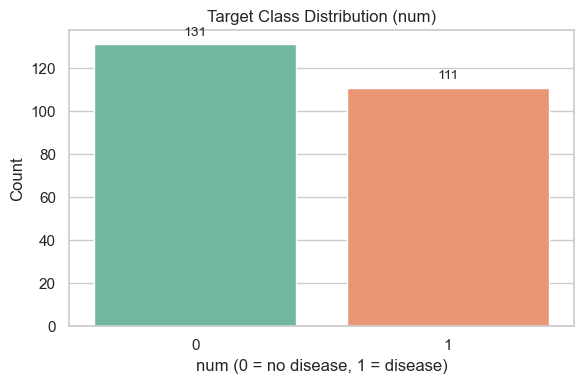

In [62]:
# Class distribution for target `num`
target_col = 'num'
class_counts = df[target_col].value_counts().sort_index()
class_percent = (df[target_col].value_counts(normalize=True).sort_index() * 100).round(2)

class_dist = pd.DataFrame({'count': class_counts, 'percent': class_percent})
display(class_dist)

plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x=target_col, hue=target_col, palette='Set2', legend=False)
ax.set_title('Target Class Distribution (num)')
ax.set_xlabel('num (0 = no disease, 1 = disease)')
ax.set_ylabel('Count')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=10, xytext=(0, 4), textcoords='offset points')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'target_class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

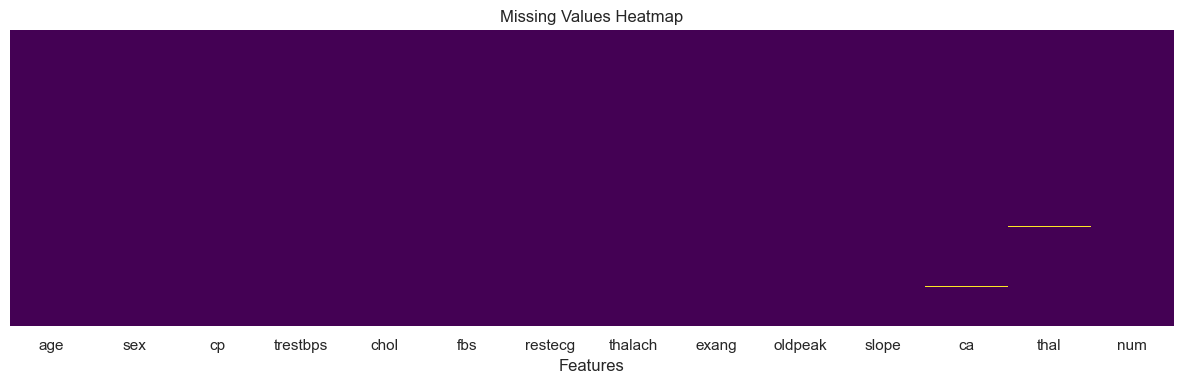

In [63]:
# Missingness visualization
plt.figure(figsize=(12, 4))
sns.heatmap(df.isna(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.xlabel('Features')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'missing_values_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

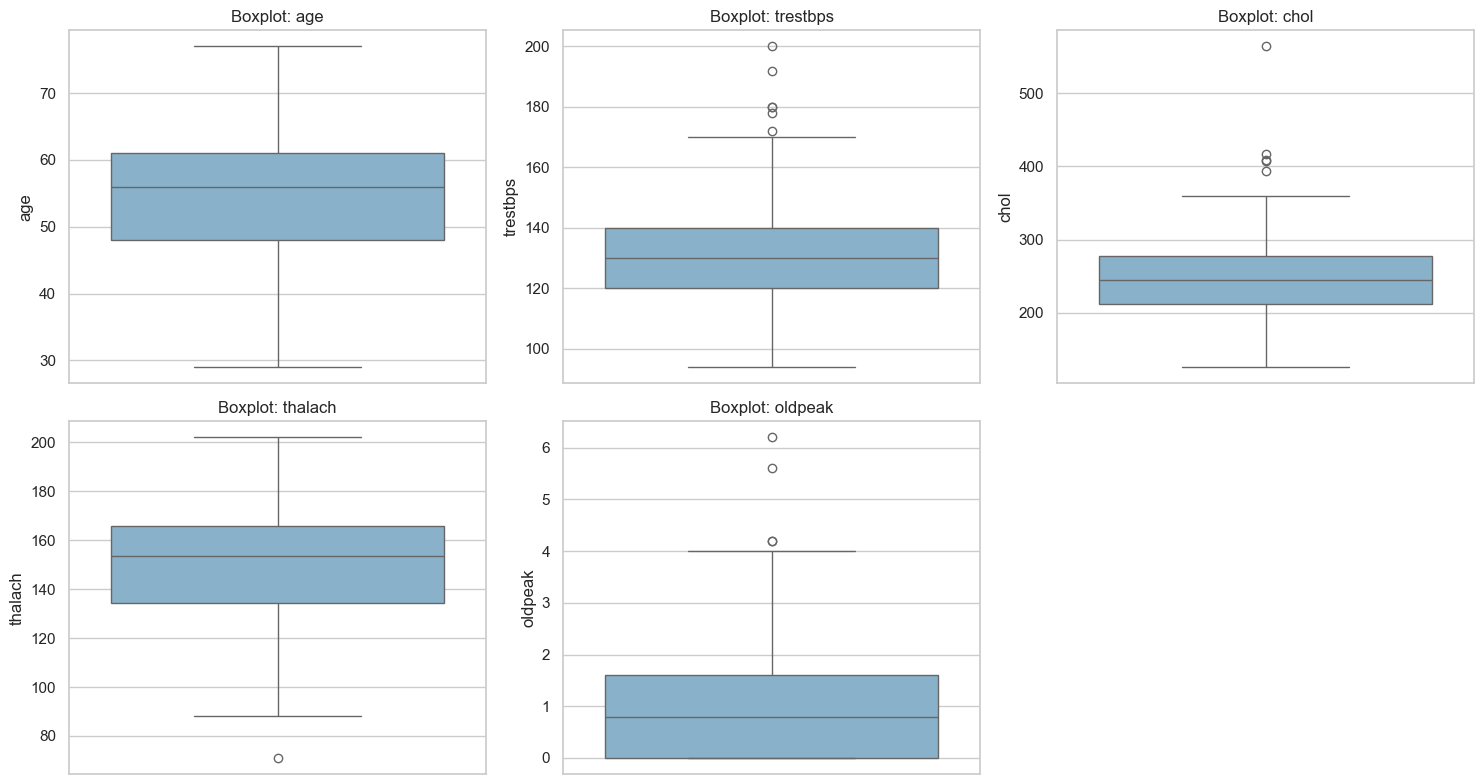

In [64]:
# Outlier assessment for continuous features using boxplots
continuous_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

n_cols = 3
n_rows = int(np.ceil(len(continuous_features) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(continuous_features):
    sns.boxplot(data=df, y=col, ax=axes[i], color='#7FB3D5')
    axes[i].set_title(f'Boxplot: {col}')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'continuous_features_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

In [65]:
# IQR-based outlier counts
outlier_counts = {}
for col in continuous_features:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_counts[col] = ((df[col] < lower) | (df[col] > upper)).sum()

outlier_df = pd.DataFrame.from_dict(outlier_counts, orient='index', columns=['n_outliers'])
outlier_df['percent'] = (outlier_df['n_outliers'] / len(df) * 100).round(2)
display(outlier_df.sort_values('n_outliers', ascending=False))

,n_outliers,percent
trestbps,6,2.48
chol,5,2.07
oldpeak,4,1.65
thalach,1,0.41
age,0,0.00


**EDA observations:**
- The dataset has the expected shape: 242 samples and 14 columns (13 predictors + `num`).
- Missing values are present in `ca` and `thal` - these must be imputed **inside CV pipelines** during modeling to avoid leakage.
- No fully duplicated rows were detected.
- The target distribution is mildly imbalanced (`num=0`: 54.1%, `num=1`: 45.9%). Later evaluation should therefore use stratified folds and clinical/class-imbalance-aware metrics such as MCC, balanced accuracy, recall/sensitivity, specificity, precision, F1, ROC-AUC and PR-AUC rather than accuracy alone.
- Several continuous variables show outliers - robust preprocessing or model choices less sensitive to outliers may help.

### Modeling implications from EDA

| Feature group | Columns | Missingness pattern | Planned handling in later modeling tasks |
|---|---|---|---|
| Continuous | `age`, `trestbps`, `chol`, `thalach`, `oldpeak` | No/limited missing values compared with `ca` and `thal` | Median imputation + scaling inside `Pipeline`/`ColumnTransformer` within CV |
| Binary | `sex`, `fbs`, `exang` | No major missingness expected | Most-frequent imputation inside CV - passthrough as 0/1 (or encode if required) |
| Categorical | `cp`, `restecg`, `slope`, `thal` | `thal` contains missing values- others should be verified from EDA table | Most-frequent imputation + one-hot encoding inside CV |
| Ordinal/count | `ca` | Missing values are present | Treat as numeric ordinal/count feature with median imputation inside CV - this conservative choice preserves count order and stays compatible with both linear and tree-based models |
| Target | `num` | No imputation applicable | Used only as target label |

Notes:
- Missing values are limited to specific columns identified in this notebook (`ca` and `thal`).
- Missing values are not imputed globally during EDA.
- All imputation and encoding will be fitted only on training folds inside later repeated nested CV pipelines to prevent leakage


## 2. Feature Assessment and Visualization

In [66]:
# Split feature types for EDA views
target_col = 'num'
X = df.drop(columns=[target_col])

categorical_like = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
continuous_like = [c for c in X.columns if c not in categorical_like]

print('Continuous-like features:', continuous_like)
print('Categorical-like features:', categorical_like)

Continuous-like features: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Categorical-like features: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']


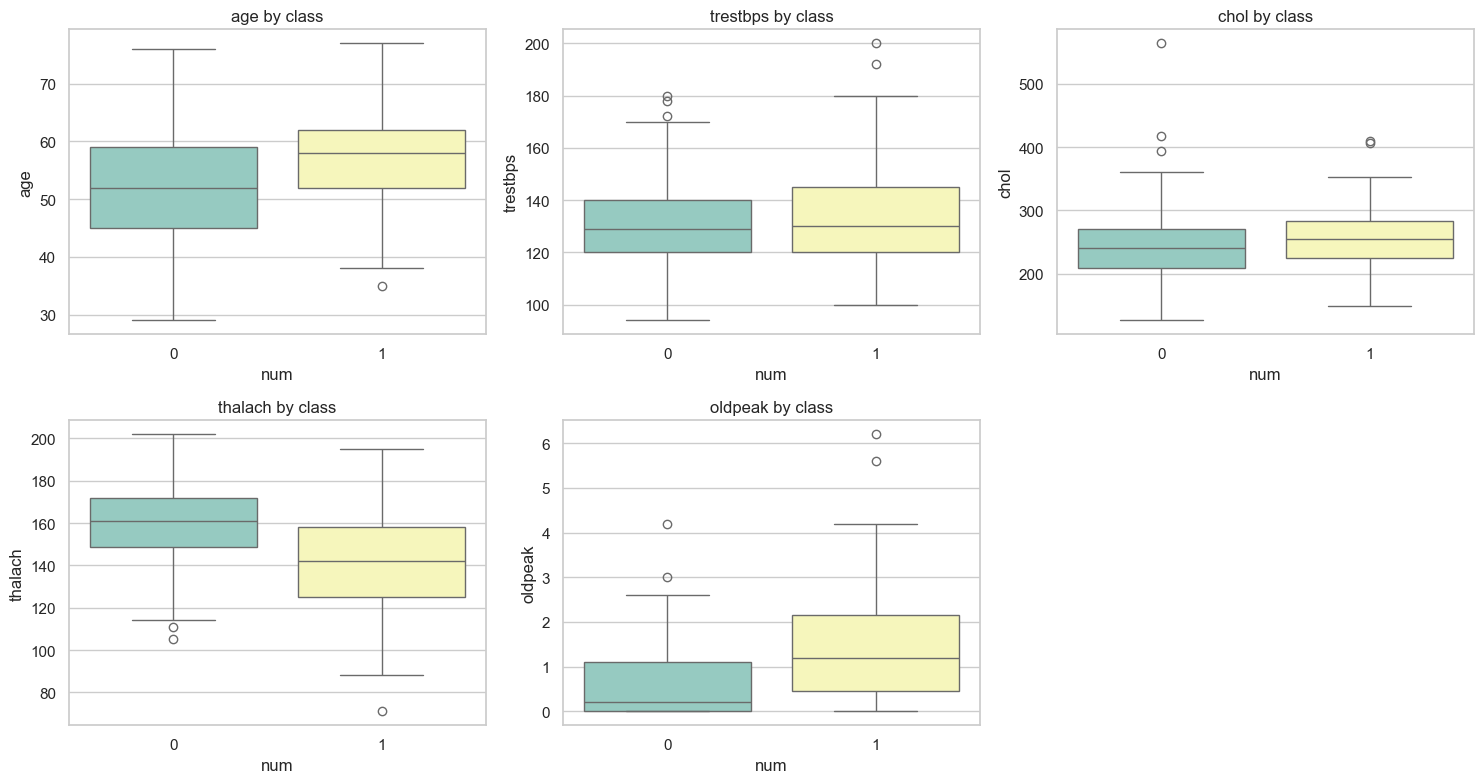

In [67]:
# Boxplots by class for continuous features
n_cols = 3
n_rows = int(np.ceil(len(continuous_like) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(continuous_like):
    sns.boxplot(data=df, x=target_col, y=col, hue=target_col, ax=axes[i], palette='Set3', legend=False)
    axes[i].set_title(f'{col} by class')
    axes[i].set_xlabel('num')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'continuous_features_by_class_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

Correlation caveat:

- Pearson/Spearman correlations involving integer-coded categorical variables are exploratory only.
- Numeric labels for `cp`, `thal`, `slope`, and `restecg` do not imply continuous distances.
- These correlations are not used directly for feature selection.
- Proper encoding and any feature selection will be performed later inside the repeated nested CV pipeline.


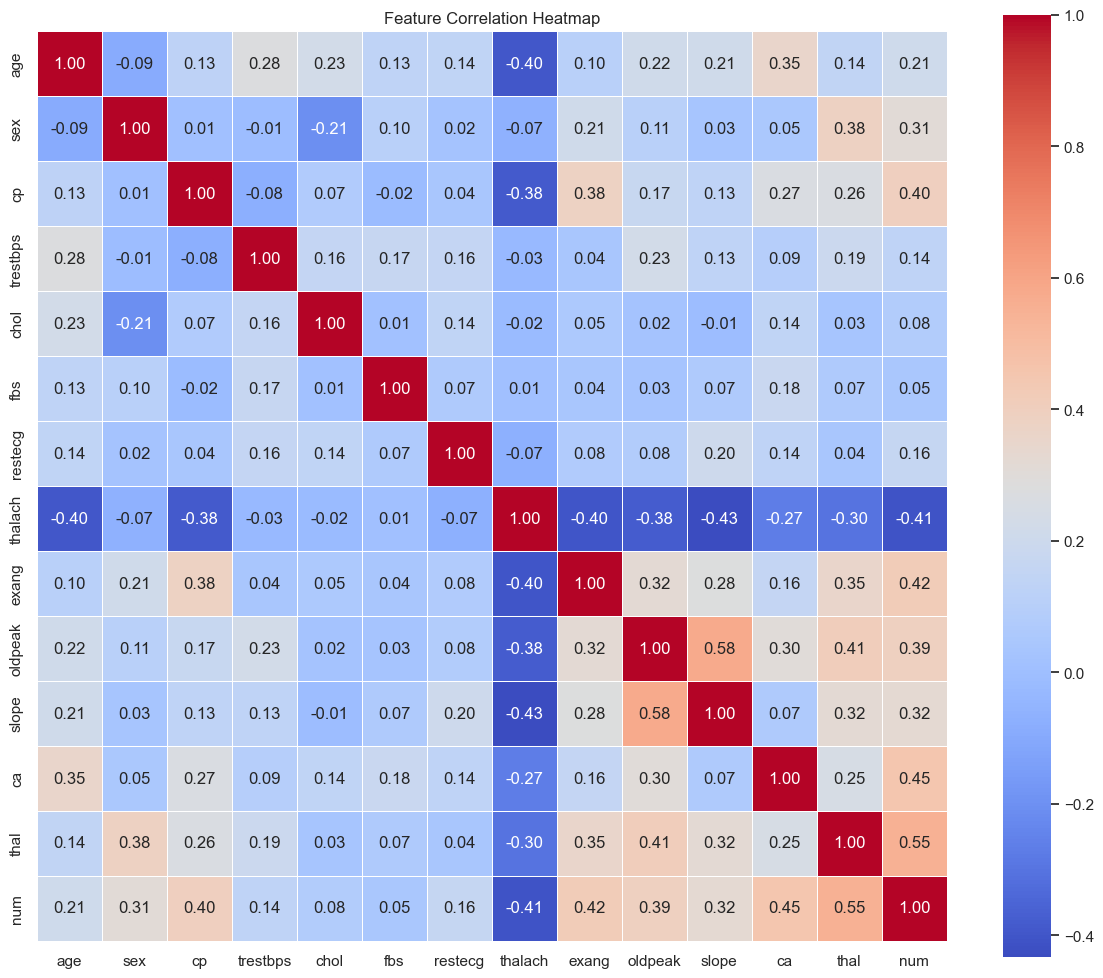

,corr_with_num
thal,0.550479
ca,0.452629
exang,0.420280
thalach,-0.409475
cp,0.400620
oldpeak,0.392151
slope,0.323349
sex,0.308342
age,0.209664
restecg,0.160363


In [68]:
# Correlation heatmap (numeric columns)
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'feature_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# Correlation with target
target_corr = corr[target_col].drop(target_col).sort_values(key=lambda s: s.abs(), ascending=False)
display(target_corr.to_frame('corr_with_num'))

PCA note:

- PCA here is used only for exploratory visualization of class separability.
- The imputer/scaler/PCA fitted in this notebook will not be reused in modeling.
- During modeling, all preprocessing will be refit inside each CV training fold to avoid leakage.


Explained variance ratio - PC1: 0.246, PC2: 0.123, Total: 0.368


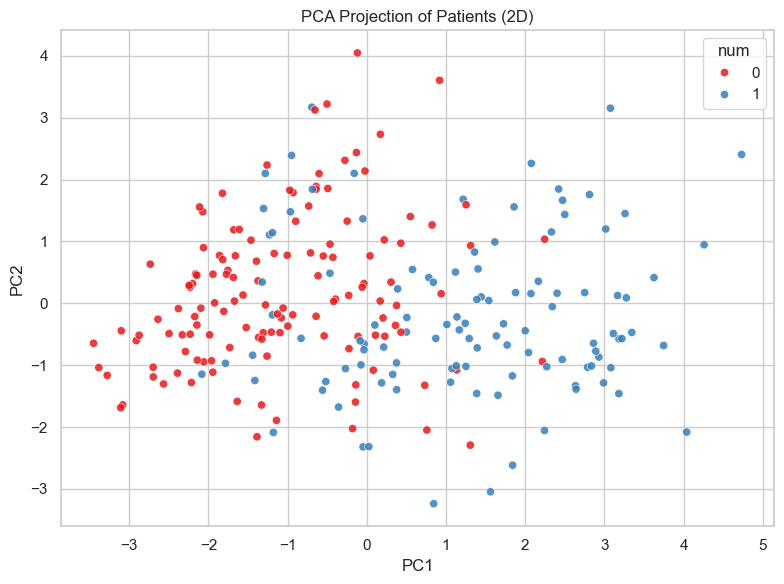

In [69]:
# Pairwise scatter in PCA space (2 components)
# NOTE: This PCA is for visualization only. During modeling, preprocessing must be fit within CV folds.
pca_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=2, random_state=SEED))
])

X_pca = pca_pipe.fit_transform(X)
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df[target_col] = df[target_col].values

expl_var = pca_pipe.named_steps['pca'].explained_variance_ratio_
print(f'Explained variance ratio - PC1: {expl_var[0]:.3f}, PC2: {expl_var[1]:.3f}, Total: {expl_var.sum():.3f}')

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue=target_col, palette='Set1', alpha=0.85)
plt.title('PCA Projection of Patients (2D)')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'pca_projection_2d.png', dpi=300, bbox_inches='tight')
plt.show()

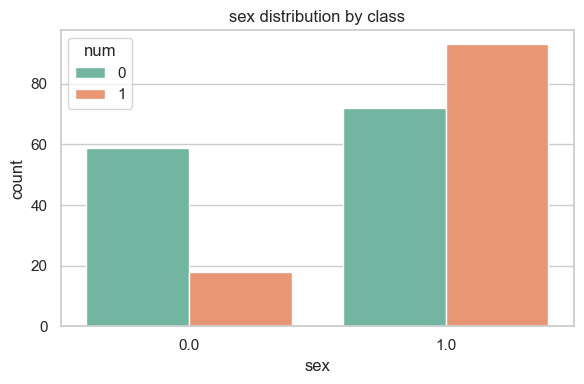

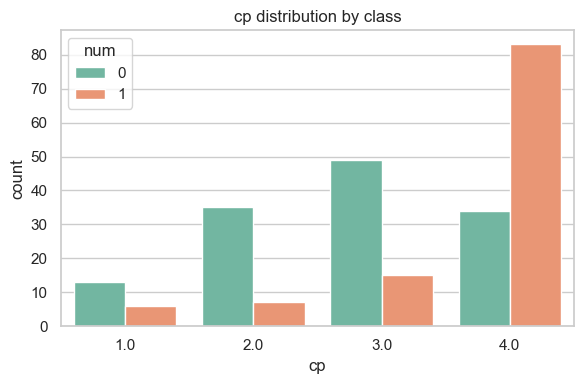

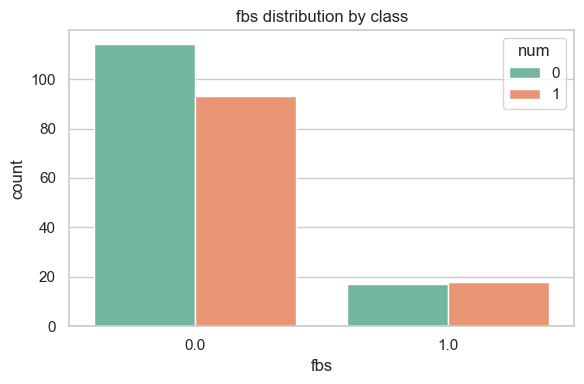

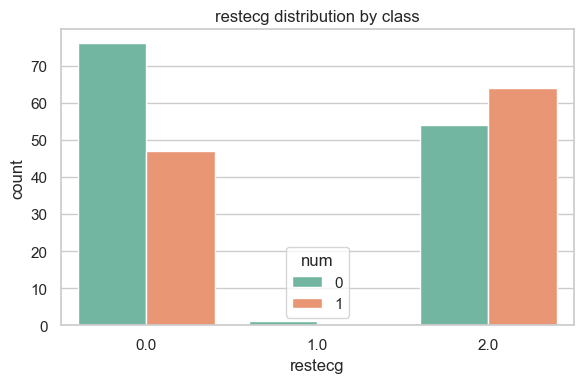

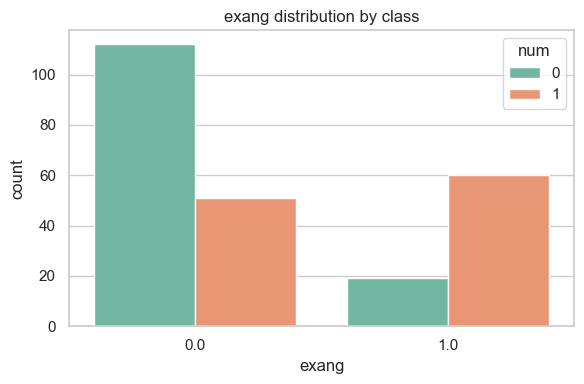

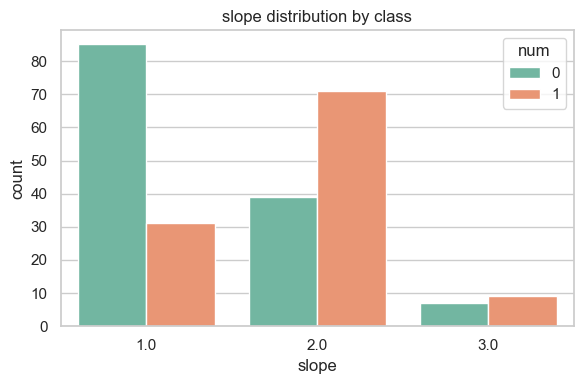

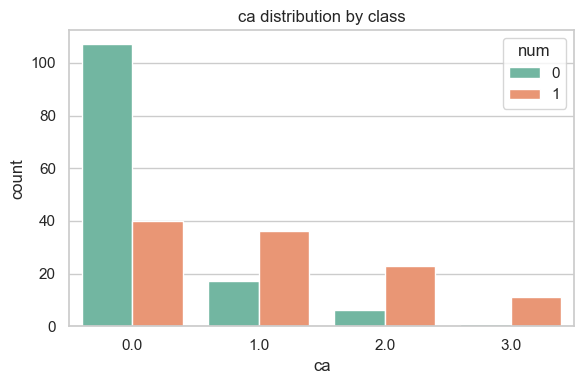

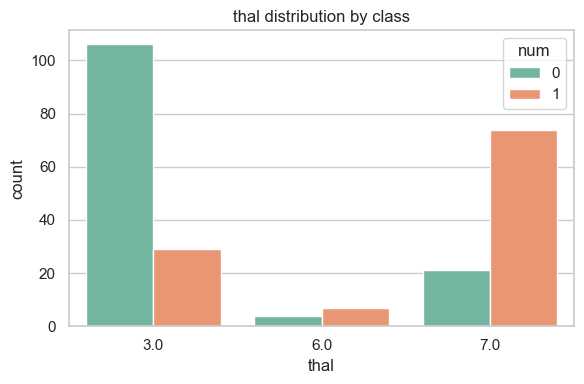

In [70]:
# categorical feature distributions by class
for col in categorical_like:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=col, hue=target_col, palette='Set2')
    plt.title(f'{col} distribution by class')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'categorical_{col}_by_class.png', dpi=300, bbox_inches='tight')
    plt.show()

**EDA observations:**
- Correlation and class-wise distributions indicate potentially informative variables such as `oldpeak`, `thalach`, `exang`, `cp`, `ca` and `thal` (confirm from tables/plots above).
- Some predictors are categorical-coded integers (`cp`, `restecg`, `slope`, `thal`, etc.). Preprocessing must treat them appropriately in modeling pipelines.
- The first two PCs show partial visual separation only. This does not determine whether linear or nonlinear classifiers will perform better. That will be assessed using repeated nested cross-validation.
- Because missingness and scaling needs differ by feature type, a `ColumnTransformer`-based pipeline is appropriate for later modeling tasks.